# Dataset Walkthrough: Raw Device Data → Synced Events → Biosignal Windows

This notebook is a runnable example of the `dataset/` pipeline built for this
project. It:

1. Builds the **canonical, host-UTC-synced** dataset for one example
   participant from the raw collection-session folder (ear-EEG, in-ear-EEG,
   wristband, Polar H10, and the task/event log), using
   `dataset/build_dataset.py`.
2. Loads the resulting event log and extracts **all event-defined windows**
   for every task (emotion, stress/raindrop, attention_highway, SART,
   attention_focus Schulte/Stroop, preparation/questionnaire), plus
   auto-detected gap/transition windows (breaks, the pre-SART gap, etc.).
3. Plots the **synced biosignals** for a few example windows: several
   emotion clips, one stress (raindrop) math tier, one highway driving
   tier, and one trial each of Stroop, Schulte, and SART.

Full design writeup (sampling rates, sync formulas, restart/opt-out
resolution rules, per-task window specs, known data-quality caveats) is in
`docs/Dataset_Sync_Design.md` at the repo root -- read that first if
anything here is surprising.

**Before running:** edit `PARTICIPANT_DIR` in the next cell to point at
whichever participant folder you want to use as the example (must exist
locally -- the raw data isn't part of this repo).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the `dataset` package importable regardless of where Jupyter was
# launched from -- walks up from the current directory until it finds the
# `dataset/` package (i.e. the repo root).
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "dataset").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from dataset.build_dataset import build_participant
from dataset.windows import load_events_parquet, extract_all_windows, windows_to_dataframe, RECOMMENDED_TRIAL_WINDOW_TYPE
from dataset.torch_dataset import load_window_biosignals, EventWindowDataset

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 100

# --- EDIT THESE FOR YOUR MACHINE ---
RAW_SESSIONS_ROOT = Path(r"C:\emotion-stress-attention-task-ear-wristband-device-data\data-collection-sessions")
PARTICIPANT_DIR = RAW_SESSIONS_ROOT / "08-14-2026-Data" / "part-P007"  # good example: in-ear device + full task set + SART
PROCESSED_OUT_DIR = REPO_ROOT / "notebooks" / "example_output"        # gitignored -- regenerated from raw data on demand
PARTICIPANT_ID = PARTICIPANT_DIR.name.split("-", 1)[1]                 # "part-P007" -> "P007"

print("Repo root:       ", REPO_ROOT)
print("Participant dir: ", PARTICIPANT_DIR)
print("Output dir:      ", PROCESSED_OUT_DIR)
print("Participant ID:  ", PARTICIPANT_ID)


Repo root:        C:\Users\UT_Wireless\Documents\biosignal-emotion-stress-attention-protocol
Participant dir:  C:\emotion-stress-attention-task-ear-wristband-device-data\data-collection-sessions\08-14-2026-Data\part-P007
Output dir:       C:\Users\UT_Wireless\Documents\biosignal-emotion-stress-attention-protocol\notebooks\example_output
Participant ID:   P007


## 1. Build the canonical synced dataset for this participant

This runs the full resolver + sync pipeline once and writes, under
`PROCESSED_OUT_DIR / PARTICIPANT_ID /`:
- one Parquet file per biosignal stream (`<device>.<role>.parquet`), each
  with a `wall_utc_s` column (absolute host-clock time) plus native columns
  at native sampling rate
- `events.parquet` (the task/event log, already host-UTC)
- `sync_report.json` -- the full audit trail: which raw file was chosen for
  each device (and why), every excluded restart/duplicate/opt-out
  candidate, sync anchors + their gap-to-log-start sanity check, and
  per-stream QC (CRC-8 ok-fraction, Polar clock-drift ppm + residuals)

Safe to re-run any time -- `build_participant` overwrites its own output.


In [2]:
report = build_participant(PARTICIPANT_DIR, PROCESSED_OUT_DIR, validate_crc=False)

n_warnings = sum(len(d["warnings"]) for d in report["devices"].values()) + len(report["global_warnings"])
print(f"Built {PARTICIPANT_ID}: {len(report['streams_written'])} streams written, {n_warnings} warning(s)\n")

for device, d in report["devices"].items():
    status = "available" if d["available"] else f"UNAVAILABLE ({d['unavailable_reason']})"
    print(f"  {device:14s} {status}")
    for w in d["warnings"]:
        print(f"      warning: {w}")

print(f"\nFull audit trail: {PROCESSED_OUT_DIR / PARTICIPANT_ID / 'sync_report.json'}")


Built P007: 15 streams written, 0 warning(s)

  ear_eeg_out    available
  ear_eeg_in     available
  wristband      available
  polar_h10      available

Full audit trail: C:\Users\UT_Wireless\Documents\biosignal-emotion-stress-attention-protocol\notebooks\example_output\P007\sync_report.json


## 2. Load the event log and extract every event-defined window

`extract_all_windows` runs every task's window extractor (see
`dataset/windows.py`) plus auto-detected gap/`"transition"` windows for any
unlabeled time (inter-task breaks, the pre-SART inter-process gap, etc.),
and returns one flat list covering the whole session (main session + the
separate SART sub-session, if present).

Window kinds (`window_type`): `"baseline"`, `"self_report"`,
`"questionnaire"`, `"transition"` (auto-detected gap), and two levels of
task performance:
- `"trial"` -- a fine-grained sub-event (one arithmetic problem, one
  obstacle, one Stroop stimulus, one SART number, one emotion clip).
- `"block"` -- one **uninterrupted run** (one raindrop/highway tier, one
  Schulte/Stroop repetition, SART's single continuous ~135-trial run).

**`"trial"` is not automatically the right atomic unit to analyze** -- for
everything except emotion, a single arithmetic problem/obstacle/stimulus is
often too fine-grained to carry much insight on its own. `RECOMMENDED_TRIAL_WINDOW_TYPE`
(imported above) is the explicit answer to "what counts as one trial" per
task: `"block"` (one uninterrupted run) for stress/attention_highway/
attention_focus_schulte/attention_focus_stroop/sart, and `"trial"` for
emotion specifically, since one clip presentation has no finer natural
sub-event to fall back to. The finer `"trial"` windows still exist for
every task if you want sub-trial-level analysis later (e.g. per-obstacle
reaction time) -- they're just not the default unit.


In [3]:
events = load_events_parquet(PROCESSED_OUT_DIR / PARTICIPANT_ID / "events.parquet")
windows = extract_all_windows(events)
windows_df = windows_to_dataframe(windows)

print(f"{len(windows)} total windows across the whole session (main + SART)\n")
windows_df.groupby(["task", "window_type"]).size().rename("count").to_frame()


878 total windows across the whole session (main + SART)



count
task                    window_type         
attention_focus_schulte baseline           3
                        block              3
attention_focus_stroop  baseline           3
                        block              3
                        trial             60
attention_highway       baseline           1
                        block              3
                        self_report        3
                        trial            518
emotion                 baseline           9
                        trial             10
preparation             questionnaire     13
sart                    baseline           1
                        block              1
                        trial            135
stress                  baseline           3
                        block              3
                        transition         2
                        trial             74
transition              transition        30

## 3. Events for each task

Per-task breakdown below (emotion, stress/raindrop, attention_highway,
attention_focus Schulte + Stroop, SART, preparation/questionnaire, and the
auto-detected transitions/gaps), showing the actual columns/labels
available for each window kind. `stimulus`/`labels`/`meta` are dict-valued
columns -- printed inline here; use `pd.json_normalize(...)` if you want a
specific task's dict column flattened into its own columns.

**Note:** `attention_highway` is a separate task from `stress` (it's
logged under `task=="attention_highway"` even though it's documented as
"the second half of the stress task") -- filtering on `task=="stress"`
alone would silently miss it.


In [4]:
emotion_df = windows_df[windows_df["task"] == "emotion"].reset_index(drop=True)
print(f"{len(emotion_df)} emotion windows "
      f"({(emotion_df.window_type == 'trial').sum()} clip trials, "
      f"{(emotion_df.window_type == 'baseline').sum()} baselines)")
emotion_df


19 emotion windows (10 clip trials, 9 baselines)


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,emotion,trial,1.786745e+09,1.786745e+09,87.378005,0.0,0.0,negative,"{'clip_id': 'clip_87', 'file_path': 'assets/clips/filmstim_negative/NEG_03.m...","{'client_perf_now_ms': 175436.40000000037, 'clip_id': 'clip_87', 'emotion_pi...",{}
1,emotion,trial,1.786745e+09,1.786745e+09,60.191073,0.0,1.0,positive,"{'clip_id': 'clip_82', 'file_path': 'assets/clips/filmstim_positive/POS_01.m...","{'client_perf_now_ms': 259571.30000000075, 'clip_id': 'clip_82', 'emotion_pi...",{}
2,emotion,trial,1.786745e+09,1.786745e+09,30.762093,0.0,2.0,neutral,"{'clip_id': 'clip_49', 'file_path': 'assets/clips/indifference/VID_1007.webm...","{'client_perf_now_ms': 311362.9000000004, 'clip_id': 'clip_49', 'emotion_pic...",{}
3,emotion,trial,1.786745e+09,1.786745e+09,95.271374,1.0,0.0,positive,"{'clip_id': 'clip_84', 'file_path': 'assets/clips/filmstim_positive/POS_03.m...","{'client_perf_now_ms': 497298.5, 'clip_id': 'clip_84', 'emotion_pick': 'Neut...",{}
4,emotion,trial,1.786745e+09,1.786745e+09,35.702260,1.0,1.0,neutral,"{'clip_id': 'clip_47', 'file_path': 'assets/clips/indifference/VID_1004.webm...","{'client_perf_now_ms': 554465.6999999993, 'clip_id': 'clip_47', 'emotion_pic...",{}
5,emotion,trial,1.786745e+09,1.786745e+09,80.192383,1.0,2.0,negative,"{'clip_id': 'clip_85', 'file_path': 'assets/clips/filmstim_negative/NEG_01.m...","{'client_perf_now_ms': 651745.5, 'clip_id': 'clip_85', 'emotion_pick': 'Nega...",{}
6,emotion,trial,1.786746e+09,1.786746e+09,38.045688,2.0,0.0,neutral,"{'clip_id': 'clip_63', 'file_path': 'assets/clips/indifference/VID_1019.webm...","{'client_perf_now_ms': 783161.5, 'clip_id': 'clip_63', 'emotion_pick': 'Neut...",{}
7,emotion,trial,1.786746e+09,1.786746e+09,67.529598,2.0,1.0,negative,"{'clip_id': 'clip_86', 'file_path': 'assets/clips/filmstim_negative/NEG_02.m...","{'client_perf_now_ms': 869168.4000000004, 'clip_id': 'clip_86', 'emotion_pic...",{}
8,emotion,trial,1.786746e+09,1.786746e+09,70.201362,2.0,2.0,positive,"{'clip_id': 'clip_83', 'file_path': 'assets/clips/filmstim_positive/POS_02.m...","{'client_perf_now_ms': 961168.8000000007, 'clip_id': 'clip_83', 'emotion_pic...",{}
9,emotion,trial,1.786746e+09,1.786746e+09,30.712128,2.0,3.0,neutral,"{'clip_id': 'clip_48', 'file_path': 'assets/clips/indifference/VID_1005.webm...","{'client_perf_now_ms': 1007768.8000000007, 'clip_id': 'clip_48', 'emotion_pi...",{}


In [5]:
stress_df = windows_df[windows_df["task"] == "stress"].reset_index(drop=True)
print(f"{len(stress_df)} stress (raindrop) windows -- by window_type:")
print(stress_df["window_type"].value_counts().to_string())
stress_df.head(10)


82 stress (raindrop) windows -- by window_type:
window_type
trial         74
baseline       3
block          3
transition     2


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,stress,baseline,1.786746e+09,1.786746e+09,10.006301,0.0,NaN,baseline,{},{},{}
1,stress,baseline,1.786746e+09,1.786746e+09,10.003002,2.0,NaN,baseline,{},{},{}
2,stress,baseline,1.786746e+09,1.786746e+09,10.003749,4.0,NaN,baseline,{},{},{}
3,stress,transition,1.786746e+09,1.786746e+09,2.016318,NaN,NaN,inter_trial_pause,{},{},{}
4,stress,transition,1.786746e+09,1.786746e+09,1.559062,NaN,NaN,inter_trial_pause,{},{},{}
5,stress,block,1.786746e+09,1.786746e+09,60.019193,1.0,NaN,tier_1,{},{},"{'tier': 1, 'accuracy': 0.6}"
6,stress,block,1.786746e+09,1.786746e+09,60.473094,3.0,NaN,tier_2,{},{},"{'tier': 2, 'accuracy': 0.5833333333333334}"
7,stress,block,1.786746e+09,1.786746e+09,60.466923,5.0,NaN,tier_3,{},{},"{'tier': 3, 'accuracy': 0.6666666666666666}"
8,stress,trial,1.786746e+09,1.786746e+09,1.666737,1.0,0.0,tier_1,"{'expression': '2 + 1', 'correct_answer': 3, 'tier': 1}","{'participant_answer': 3, 'rt': 1.668800000000745, 'correct': True, 'missed'...",{}
9,stress,trial,1.786746e+09,1.786746e+09,2.573948,1.0,1.0,tier_1,"{'expression': '81 * 4', 'correct_answer': 324, 'tier': 1}","{'participant_answer': 324, 'rt': 2.573900000002235, 'correct': True, 'misse...",{}


In [6]:
highway_df = windows_df[windows_df["task"] == "attention_highway"].reset_index(drop=True)
print(f"{len(highway_df)} attention_highway windows -- by window_type:")
print(highway_df["window_type"].value_counts().to_string())
highway_df.head(10)


525 attention_highway windows -- by window_type:
window_type
trial          518
block            3
self_report      3
baseline         1


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,attention_highway,baseline,1.786746e+09,1.786746e+09,5.010206,0.0,NaN,baseline,{},{},{}
1,attention_highway,block,1.786746e+09,1.786746e+09,61.074959,1.0,NaN,tier_1,{},{},"{'tier': 1, 'nominal_difficulty': 1, 'avoided': 107, 'collisions': 0}"
2,attention_highway,block,1.786746e+09,1.786746e+09,60.771399,2.0,NaN,tier_2,{},{},"{'tier': 2, 'nominal_difficulty': 2, 'avoided': 133, 'collisions': 2}"
3,attention_highway,block,1.786746e+09,1.786746e+09,60.927402,3.0,NaN,tier_3,{},{},"{'tier': 3, 'nominal_difficulty': 3, 'avoided': 235, 'collisions': 41}"
4,attention_highway,trial,1.786746e+09,1.786746e+09,2.014946,1.0,0.0,tier_1,"{'lane': 2, 'fall_duration_sec': 2}","{'outcome': 'avoided', 'near_miss': False, 'reaction_margin_sec': 1.23189999...",{}
5,attention_highway,trial,1.786746e+09,1.786746e+09,2.015944,1.0,1.0,tier_1,"{'lane': 2, 'fall_duration_sec': 2}","{'outcome': 'avoided', 'near_miss': False, 'reaction_margin_sec': None, 'res...",{}
6,attention_highway,trial,1.786746e+09,1.786746e+09,2.016727,1.0,2.0,tier_1,"{'lane': 3, 'fall_duration_sec': 2}","{'outcome': 'avoided', 'near_miss': False, 'reaction_margin_sec': None, 'res...",{}
7,attention_highway,trial,1.786746e+09,1.786746e+09,2.017237,1.0,3.0,tier_1,"{'lane': 3, 'fall_duration_sec': 2}","{'outcome': 'avoided', 'near_miss': False, 'reaction_margin_sec': None, 'res...",{}
8,attention_highway,trial,1.786746e+09,1.786746e+09,2.002717,1.0,4.0,tier_1,"{'lane': 1, 'fall_duration_sec': 2}","{'outcome': 'avoided', 'near_miss': False, 'reaction_margin_sec': 1.38419999...",{}
9,attention_highway,trial,1.786746e+09,1.786746e+09,2.015747,1.0,5.0,tier_1,"{'lane': 2, 'fall_duration_sec': 2}","{'outcome': 'avoided', 'near_miss': False, 'reaction_margin_sec': 1.01819999...",{}


In [7]:
focus_df = windows_df[windows_df["task"].isin(["attention_focus_schulte", "attention_focus_stroop"])].reset_index(drop=True)
print(f"{len(focus_df)} attention_focus windows (Schulte + Stroop) -- by task/window_type:")
print(focus_df.groupby(["task", "window_type"]).size().to_string())
focus_df.head(10)


72 attention_focus windows (Schulte + Stroop) -- by task/window_type:
task                     window_type
attention_focus_schulte  baseline        3
                         block           3
attention_focus_stroop   baseline        3
                         block           3
                         trial          60


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,attention_focus_schulte,baseline,1.786747e+09,1.786747e+09,10.004269,0.0,NaN,baseline,{},{},{'session_trial_index': 0}
1,attention_focus_schulte,block,1.786747e+09,1.786747e+09,24.739221,1.0,NaN,schulte_trial,{},"{'client_perf_now_ms': 37302.89999999851, 'grid_size': 5, 'skipped': False, ...",{'session_trial_index': 0}
2,attention_focus_schulte,baseline,1.786747e+09,1.786747e+09,10.005313,0.0,NaN,baseline,{},{},{'session_trial_index': 1}
3,attention_focus_schulte,block,1.786747e+09,1.786747e+09,23.978895,1.0,NaN,schulte_trial,{},"{'client_perf_now_ms': 35637, 'grid_size': 5, 'skipped': False, 'completion_...",{'session_trial_index': 1}
4,attention_focus_schulte,baseline,1.786747e+09,1.786747e+09,10.009028,0.0,NaN,baseline,{},{},{'session_trial_index': 2}
5,attention_focus_schulte,block,1.786747e+09,1.786747e+09,25.542000,1.0,NaN,schulte_trial,{},"{'client_perf_now_ms': 37350.60000000149, 'grid_size': 5, 'skipped': False, ...",{'session_trial_index': 2}
6,attention_focus_stroop,baseline,1.786746e+09,1.786746e+09,10.011744,0.0,NaN,baseline,{},{},{'session_trial_index': 0}
7,attention_focus_stroop,block,1.786746e+09,1.786746e+09,46.555476,1.0,NaN,stroop_trial,{},"{'client_perf_now_ms': 59828.5, 'skipped': False, 'accuracy': 1, 'mean_rt_ms...",{'session_trial_index': 0}
8,attention_focus_stroop,trial,1.786746e+09,1.786746e+09,1.430896,1.0,0.0,stroop_trial,"{'word': 'purple', 'ink_color': 'pink', 'congruent': False}","{'clicked_color': 'pink', 'correct': True, 'rt_ms': 1429.9000000022352}",{'session_trial_index': 0}
9,attention_focus_stroop,trial,1.786746e+09,1.786746e+09,1.184436,1.0,1.0,stroop_trial,"{'word': 'purple', 'ink_color': 'blue', 'congruent': False}","{'clicked_color': 'blue', 'correct': True, 'rt_ms': 1185}",{'session_trial_index': 0}


In [8]:
sart_df = windows_df[windows_df["task"] == "sart"].reset_index(drop=True)
print(f"{len(sart_df)} SART windows -- by window_type:")
print(sart_df["window_type"].value_counts().to_string())
sart_df.head(10)


137 SART windows -- by window_type:
window_type
trial       135
baseline      1
block         1


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,sart,baseline,1.786747e+09,1.786747e+09,30.025454,NaN,NaN,None,{},{},{'position': 'pre_task'}
1,sart,block,1.786747e+09,1.786747e+09,156.295574,1.0,NaN,None,{},{},{'practice': False}
2,sart,trial,1.786747e+09,1.786747e+09,1.159006,1.0,0.0,None,"{'number': 1, 'font_size': 85.33, 'is_omit': False}","{'responded': True, 'rt': 1.0575148000025365, 'accurate': True}",{'practice': False}
3,sart,trial,1.786747e+09,1.786747e+09,1.160251,1.0,1.0,None,"{'number': 8, 'font_size': 80.21, 'is_omit': True}","{'responded': True, 'rt': 0.619487100000697, 'accurate': False}",{'practice': False}
4,sart,trial,1.786747e+09,1.786747e+09,1.157404,1.0,2.0,None,"{'number': 1, 'font_size': 61.44, 'is_omit': False}","{'responded': True, 'rt': 0.43614119999983814, 'accurate': True}",{'practice': False}
5,sart,trial,1.786747e+09,1.786747e+09,1.157090,1.0,3.0,None,"{'number': 8, 'font_size': 61.44, 'is_omit': True}","{'responded': False, 'rt': None, 'accurate': True}",{'practice': False}
6,sart,trial,1.786747e+09,1.786747e+09,1.158375,1.0,4.0,None,"{'number': 4, 'font_size': 102.4, 'is_omit': False}","{'responded': True, 'rt': 0.48985150000225985, 'accurate': True}",{'practice': False}
7,sart,trial,1.786747e+09,1.786747e+09,1.155758,1.0,5.0,None,"{'number': 8, 'font_size': 102.4, 'is_omit': True}","{'responded': False, 'rt': None, 'accurate': True}",{'practice': False}
8,sart,trial,1.786747e+09,1.786747e+09,1.159175,1.0,6.0,None,"{'number': 2, 'font_size': 85.33, 'is_omit': False}","{'responded': True, 'rt': 0.5506065000008675, 'accurate': True}",{'practice': False}
9,sart,trial,1.786747e+09,1.786747e+09,1.157197,1.0,7.0,None,"{'number': 6, 'font_size': 40.96, 'is_omit': False}","{'responded': True, 'rt': 0.6636021000012988, 'accurate': True}",{'practice': False}


In [9]:
prep_df = windows_df[windows_df["task"] == "preparation"].reset_index(drop=True)
print(f"{len(prep_df)} preparation/questionnaire windows")
prep_df


13 preparation/questionnaire windows


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,preparation,questionnaire,1.786745e+09,1.786745e+09,4.0397,NaN,NaN,None,{},"{'item_id': 'age_range', 'value': '18-24'}",{}
1,preparation,questionnaire,1.786745e+09,1.786745e+09,4.4315,NaN,NaN,None,{},"{'item_id': 'gender', 'value': 'Female'}",{}
2,preparation,questionnaire,1.786745e+09,1.786745e+09,10.4877,NaN,NaN,None,{},"{'item_id': 'education', 'value': 'High school diploma / GED'}",{}
3,preparation,questionnaire,1.786745e+09,1.786745e+09,13.2879,NaN,NaN,None,{},"{'item_id': 'native_language', 'value': 'English'}",{}
4,preparation,questionnaire,1.786745e+09,1.786745e+09,3.3035,NaN,NaN,None,{},"{'item_id': 'handedness', 'value': 'Right-handed'}",{}
5,preparation,questionnaire,1.786745e+09,1.786745e+09,3.6316,NaN,NaN,None,{},"{'item_id': 'sleep_hours_last_night', 'value': 8}",{}
6,preparation,questionnaire,1.786745e+09,1.786745e+09,1.7517,NaN,NaN,None,{},"{'item_id': 'caffeine_last_3h', 'value': 'No'}",{}
7,preparation,questionnaire,1.786745e+09,1.786745e+09,3.3435,NaN,NaN,None,{},"{'item_id': 'stai_calm', 'value': 4}",{}
8,preparation,questionnaire,1.786745e+09,1.786745e+09,6.0476,NaN,NaN,None,{},"{'item_id': 'stai_tense', 'value': 2}",{}
9,preparation,questionnaire,1.786745e+09,1.786745e+09,7.5915,NaN,NaN,None,{},"{'item_id': 'stai_upset', 'value': 1}",{}


In [10]:
transition_df = windows_df[windows_df["window_type"] == "transition"].sort_values("duration_s", ascending=False).reset_index(drop=True)
print(f"{len(transition_df)} auto-detected transition/gap windows (largest first) --")
print("these cover inter-task breaks, the pre-SART inter-process gap, and any other unlabeled time:")
transition_df.head(15)


32 auto-detected transition/gap windows (largest first) --
these cover inter-task breaks, the pre-SART inter-process gap, and any other unlabeled time:


,task,window_type,t_start,t_end,duration_s,block_index,trial_index,condition_label,stimulus,labels,meta
0,transition,transition,1.786746e+09,1.786746e+09,82.448582,NaN,NaN,None,{},{},"{'preceding_task': 'attention_highway', 'preceding_event_type': 'self_report..."
1,transition,transition,1.786746e+09,1.786746e+09,70.184769,NaN,NaN,None,{},{},"{'preceding_task': 'emotion', 'preceding_event_type': 'baseline_end', 'follo..."
2,transition,transition,1.786747e+09,1.786747e+09,56.657228,NaN,NaN,None,{},{},"{'preceding_task': 'attention_focus_stroop', 'preceding_event_type': 'block_..."
3,transition,transition,1.786745e+09,1.786745e+09,25.786042,NaN,NaN,None,{},{},"{'preceding_task': 'emotion', 'preceding_event_type': 'clip_playback_end', '..."
4,transition,transition,1.786746e+09,1.786746e+09,22.360028,NaN,NaN,None,{},{},"{'preceding_task': 'attention_focus_stroop', 'preceding_event_type': 'task_e..."
5,transition,transition,1.786746e+09,1.786746e+09,20.778120,NaN,NaN,None,{},{},"{'preceding_task': 'emotion', 'preceding_event_type': 'clip_playback_end', '..."
6,transition,transition,1.786745e+09,1.786745e+09,18.943168,NaN,NaN,None,{},{},"{'preceding_task': 'emotion', 'preceding_event_type': 'clip_playback_end', '..."
7,transition,transition,1.786746e+09,1.786746e+09,16.790116,NaN,NaN,None,{},{},"{'preceding_task': 'emotion', 'preceding_event_type': 'clip_playback_end', '..."
8,transition,transition,1.786745e+09,1.786745e+09,16.460896,NaN,NaN,None,{},{},"{'preceding_task': 'emotion', 'preceding_event_type': 'clip_playback_end', '..."
9,transition,transition,1.786747e+09,1.786747e+09,16.455035,NaN,NaN,None,{},{},{'reason': 'gap between main session end and SART sub-session start (separat...


## 4. Plot synced biosignals for example windows

`load_window_biosignals` slices every available biosignal stream to one
window's `[t_start, t_end]` and (optionally) resamples it onto a common
target rate -- the same function `EventWindowDataset` uses internally,
exposed standalone here. The helper below plots each stream as its own row;
multi-channel streams (8ch EEG, 6ch IMU) are drawn with a per-channel
vertical offset (scaled by that channel's own std) so traces don't overlap.

Only streams with at least one sample in the window are plotted -- e.g. a
participant who opted out of the in-ear device, or a sensor that dropped
out, simply won't have that row.


In [11]:
DEFAULT_PLOT_STREAMS = ["ear_eeg_out.ads1299", "wristband.gsr", "wristband.ppg", "wristband.imu", "polar_h10.ecg"]


def plot_window(window, streams=None, target_hz=None, title=None):
    streams = streams or DEFAULT_PLOT_STREAMS
    bio = load_window_biosignals(PROCESSED_OUT_DIR, PARTICIPANT_ID, window, streams=streams, target_hz=target_hz)
    if not bio:
        print(f"No biosignal data available for this window ({window.task}/{window.window_type}).")
        return

    fig, axes = plt.subplots(len(bio), 1, figsize=(11, 2.0 * len(bio)), sharex=True, squeeze=False)
    axes = axes[:, 0]
    for ax, (stream, entry) in zip(axes, bio.items()):
        t_rel, values, cols = entry["t_rel_s"], entry["values"], entry["columns"]
        offset = 0.0
        for i, col in enumerate(cols):
            y = values[:, i]
            if len(cols) > 1:
                spread = np.nanstd(y) or 1.0
                ax.plot(t_rel, y + offset, linewidth=0.6, label=col)
                offset += 6 * spread
            else:
                ax.plot(t_rel, y, linewidth=0.8, label=col)
        ax.set_ylabel(stream, fontsize=8)
        ax.legend(loc="upper right", fontsize=6, ncol=min(len(cols), 4))
    axes[-1].set_xlabel("time within window (s)")
    dur = window.t_end - window.t_start
    fig.suptitle(title or f"{window.task} / {window.window_type}  (dur={dur:.1f}s, cond={window.condition_label})")
    fig.tight_layout()
    plt.show()


### A few emotion video clips

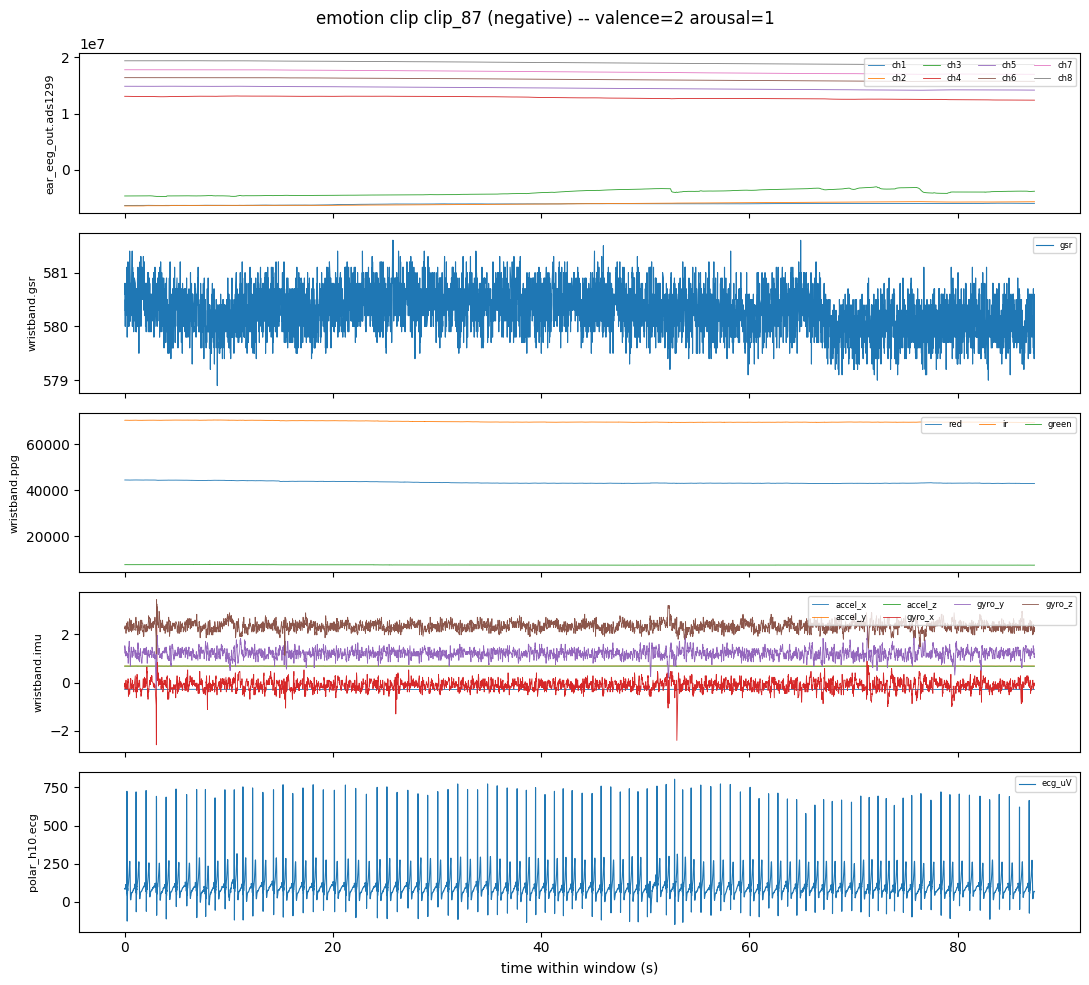

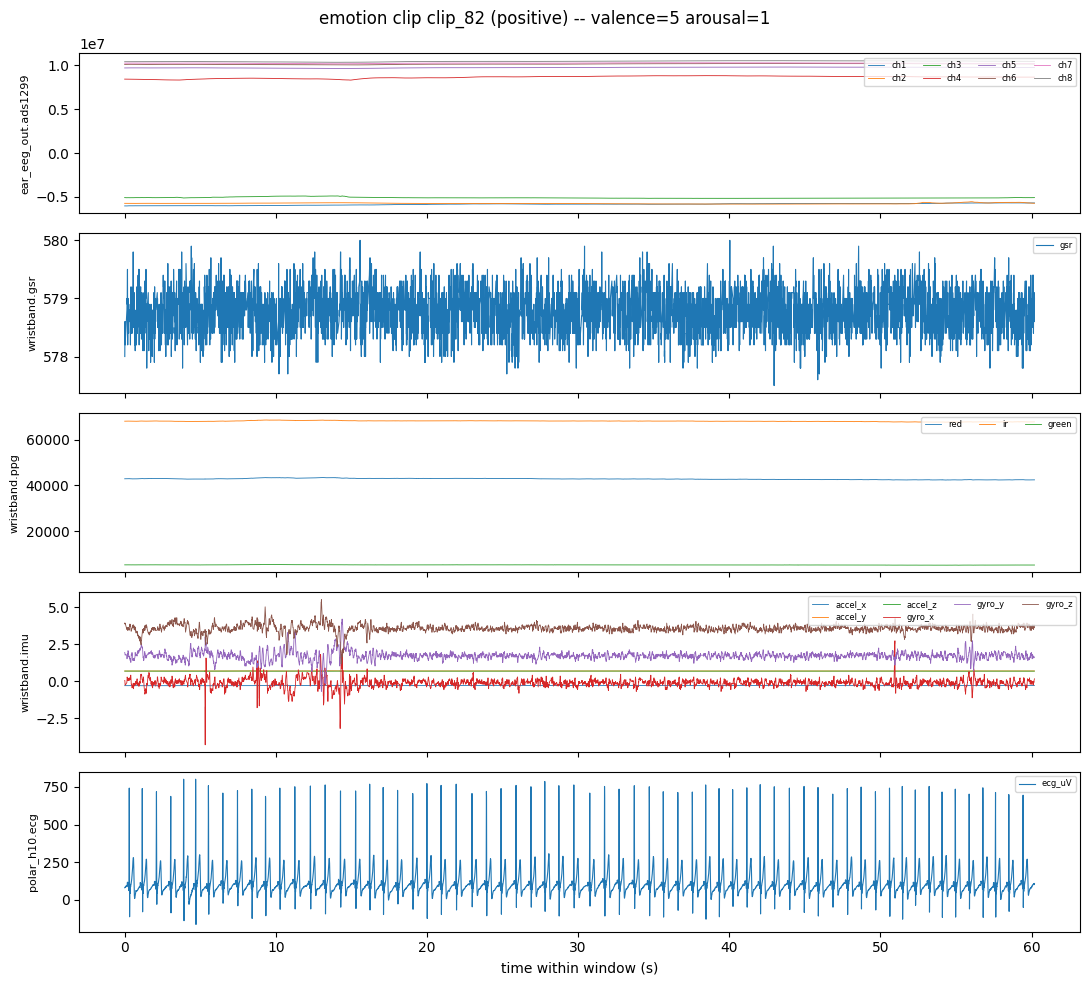

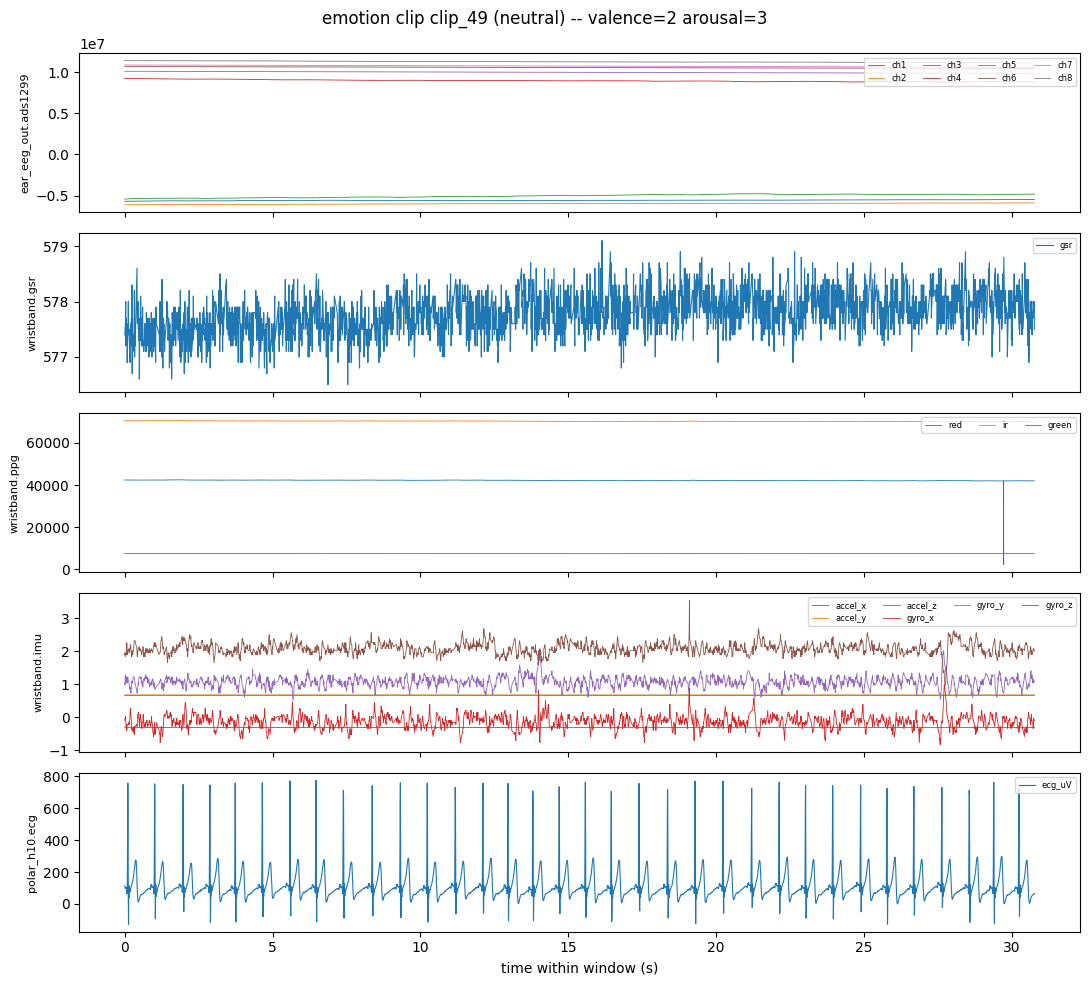

In [12]:
emotion_trials = [w for w in windows if w.task == "emotion" and w.window_type == RECOMMENDED_TRIAL_WINDOW_TYPE["emotion"]]
for w in emotion_trials[:3]:
    plot_window(
        w,
        title=f"emotion clip {w.stimulus.get('clip_id')} ({w.condition_label}) -- "
              f"valence={w.labels.get('valence')} arousal={w.labels.get('arousal')}",
    )


### One raindrop (mental-arithmetic stress) tier -- one full uninterrupted run

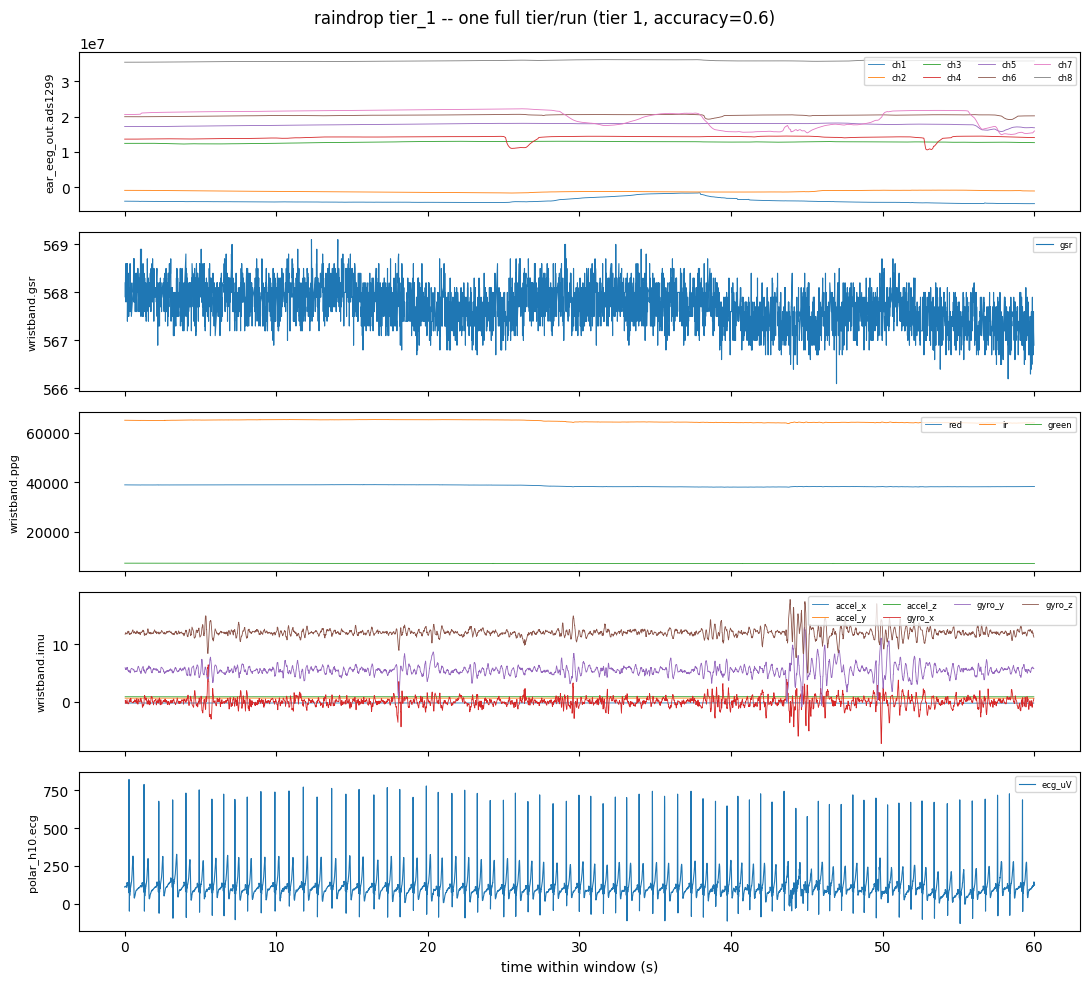

In [13]:
raindrop_runs = [w for w in windows if w.task == "stress" and w.window_type == RECOMMENDED_TRIAL_WINDOW_TYPE["stress"]]
w = raindrop_runs[0]
plot_window(w, title=f"raindrop {w.condition_label} -- one full tier/run (tier {w.meta.get('tier')}, accuracy={w.meta.get('accuracy')})")


### One highway driving (attention/stress) tier -- one full uninterrupted run

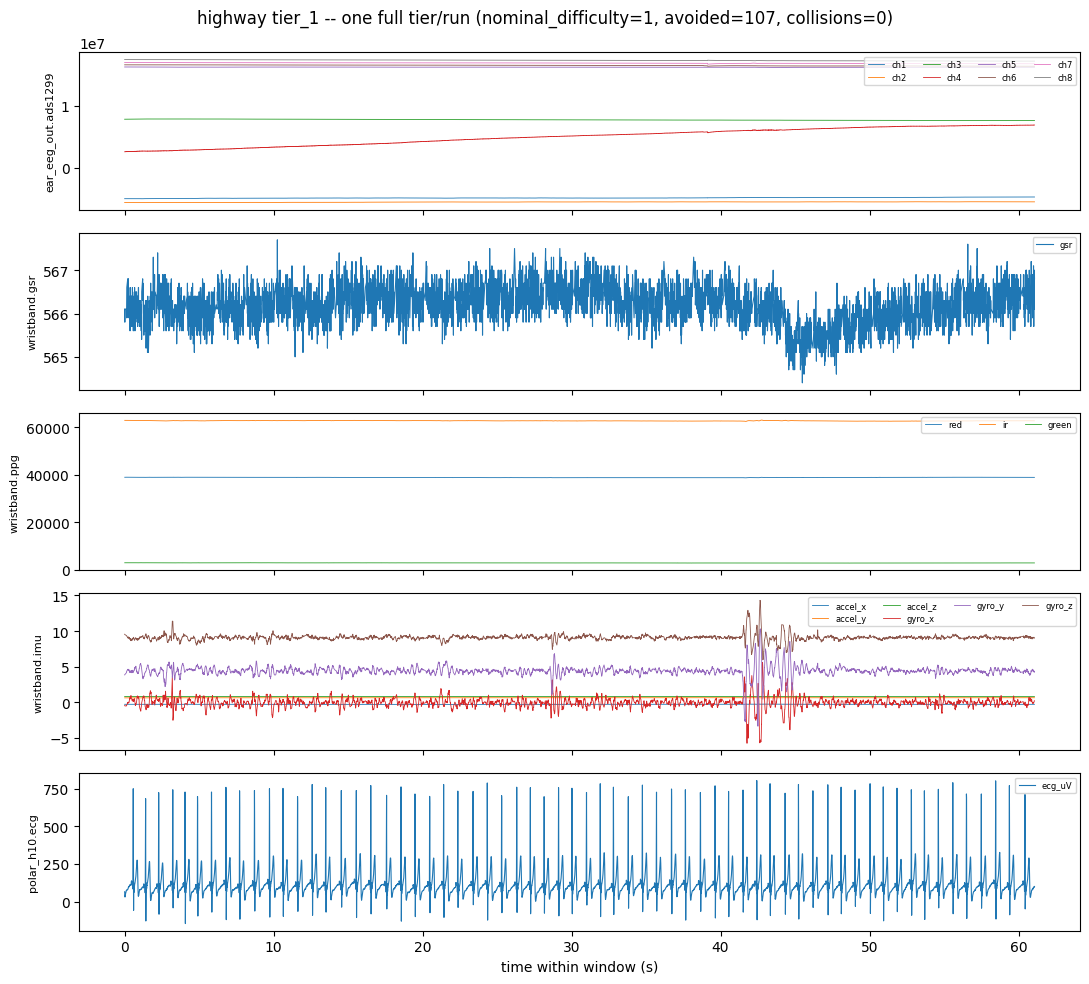

In [14]:
highway_runs = [w for w in windows if w.task == "attention_highway" and w.window_type == RECOMMENDED_TRIAL_WINDOW_TYPE["attention_highway"]]
w = highway_runs[0]
plot_window(
    w,
    title=f"highway {w.condition_label} -- one full tier/run (nominal_difficulty={w.meta.get('nominal_difficulty')}, "
          f"avoided={w.meta.get('avoided')}, collisions={w.meta.get('collisions')})",
)


### One Stroop trial, one Schulte trial, one SART trial (each = one full uninterrupted run, per `RECOMMENDED_TRIAL_WINDOW_TYPE`)

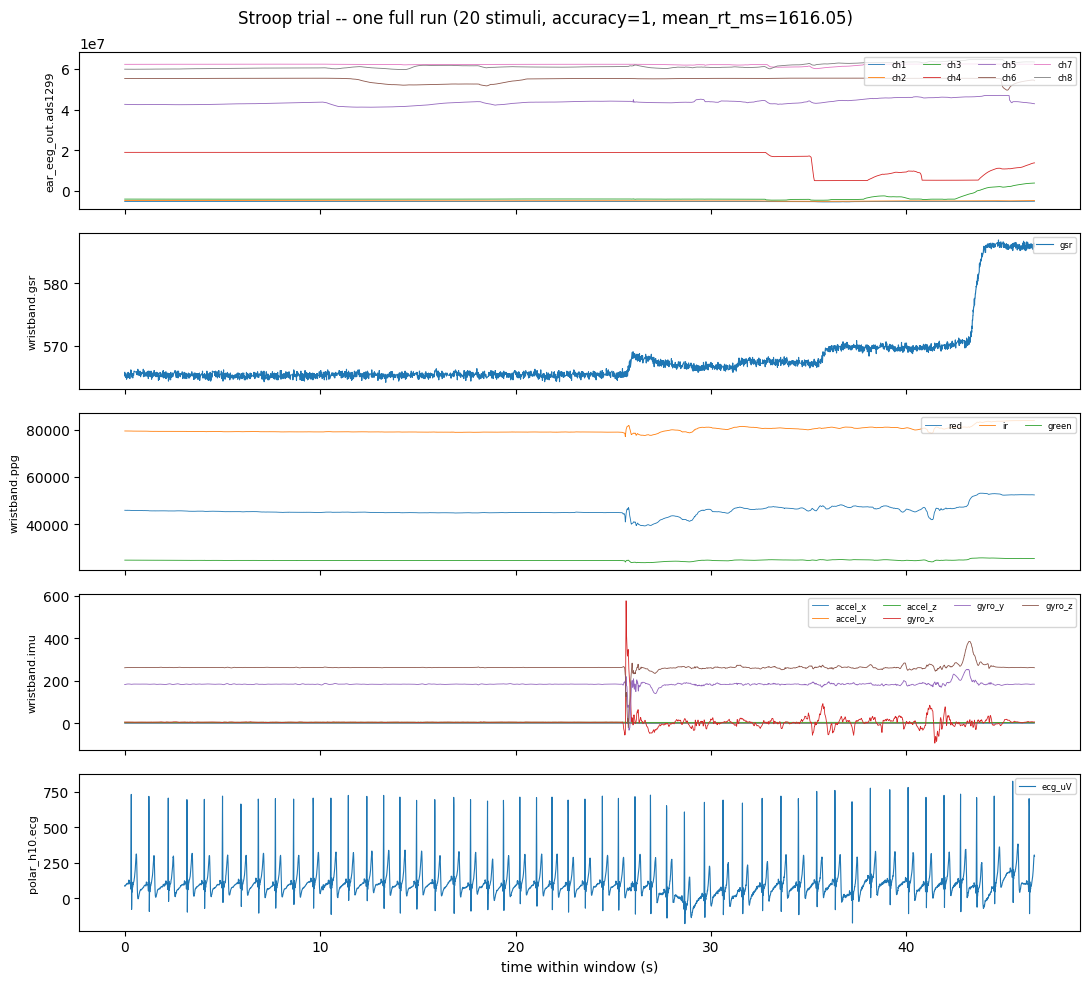

In [15]:
stroop_runs = [w for w in windows if w.task == "attention_focus_stroop" and w.window_type == RECOMMENDED_TRIAL_WINDOW_TYPE["attention_focus_stroop"]]
w = stroop_runs[0]
plot_window(w, title=f"Stroop trial -- one full run (20 stimuli, accuracy={w.labels.get('accuracy')}, mean_rt_ms={w.labels.get('mean_rt_ms')})")


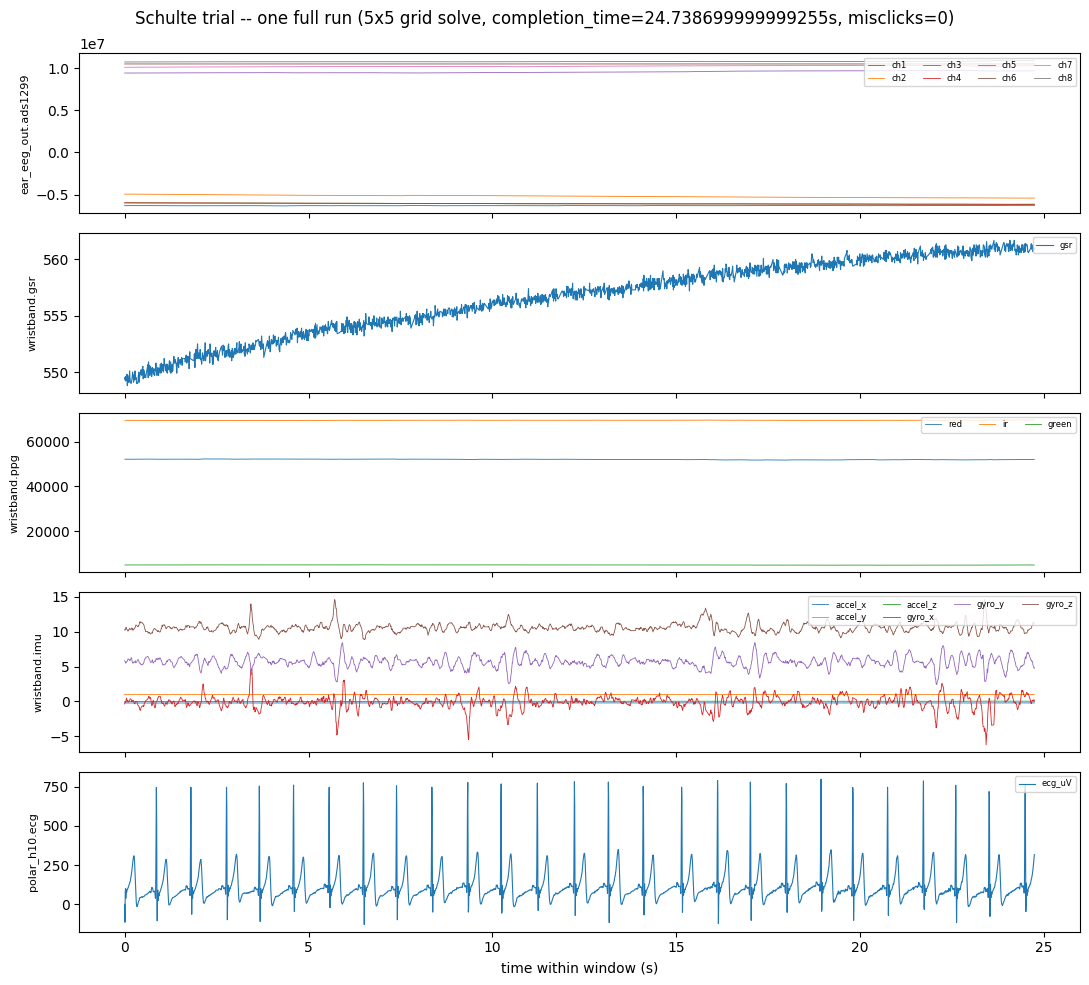

In [16]:
schulte_runs = [w for w in windows if w.task == "attention_focus_schulte" and w.window_type == RECOMMENDED_TRIAL_WINDOW_TYPE["attention_focus_schulte"]]
w = schulte_runs[0]
plot_window(w, title=f"Schulte trial -- one full run (5x5 grid solve, completion_time={w.labels.get('completion_time_sec')}s, misclicks={w.labels.get('misclicks')})")


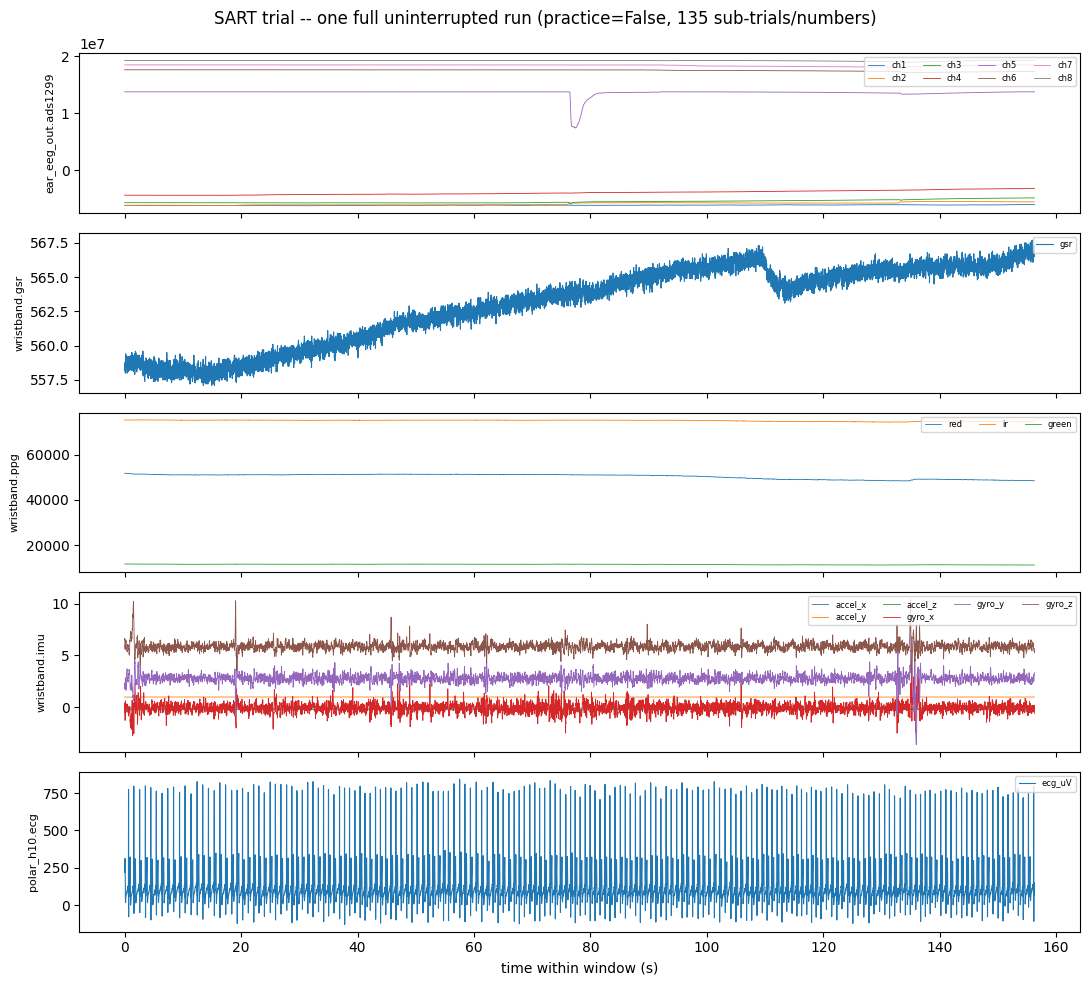

In [17]:
sart_runs = [w for w in windows if w.task == "sart" and w.window_type == RECOMMENDED_TRIAL_WINDOW_TYPE["sart"]]
w = sart_runs[0]
n_sub_trials = sum(1 for x in windows if x.task == "sart" and x.window_type == "trial" and x.block_index == w.block_index)
plot_window(w, title=f"SART trial -- one full uninterrupted run (practice={w.meta.get('practice')}, {n_sub_trials} sub-trials/numbers)")


## 5. Next steps for DL/ML processing

- `dataset/torch_dataset.py`'s `EventWindowDataset` gives you a
  PyTorch-`Dataset`-shaped object (`__len__`/`__getitem__`) directly over
  these windows -- filter with `tasks=`/`window_types=` (e.g.
  `window_types=["baseline"]` for a resting-vs-task contrast across every
  task at once). Windows have variable length/streams, so wrapping it in a
  real `torch.utils.data.DataLoader` needs a custom `collate_fn`.
- Build the canonical dataset for the **whole cohort** at once with:
  ```
  python -m dataset.build_dataset --root <sessions_root> --out-dir <out_dir>
  ```
- Before training on `attention_highway` data, read
  `docs/Dataset_Sync_Design.md`'s caveat about the first 4 participants'
  obstacle-scoring bug (`notes/notes.txt`, fixed 2026-08-13) -- their trial
  counts are inflated ~2x vs. later participants for the same config.
- Per-participant manual sync fixes (each with a documented reason) live in
  `dataset/overrides.yaml` -- e.g. P006/P009's wristband session handling.
- Each participant's `sync_report.json` (written next to the Parquet
  output) is the full audit trail for exactly which raw files were used and
  why -- check it before trusting any participant's data blindly,
  especially ones with device restarts or opt-outs.
